In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

In [ ]:
from superconductivity.utilities.constants import G0_muS
from superconductivity.utilities.meta.axis import axis
from superconductivity.utilities.meta.param import param

Vbias_mV = axis("V_mV", -1.0, 1.0, 2001, order=0)
Abias_mV = axis("A_mV", 0, 0.3, 1001, order=1)
T_K = param("T_K", 0.236)
GN_G0 = param("GN_G0", 0.2)
Delta_meV = param("Delta_meV", 0.18)
gamma_meV = param("gamma_meV", 0.0)

from superconductivity.models.bcs import get_Ibcs_nA

I_nA = get_Ibcs_nA(
    V_mV=Vbias_mV.values,
    GN_G0=GN_G0.value,
    T_K=T_K.value,
    Delta_meV=Delta_meV.value,
    gamma_meV=0.00,
    A_mV=Abias_mV.values,
    nu_GHz=10.0,
)


I_nA

array([[-15.34558868, -15.32966053, -15.31373238, ...,  15.31373238,
         15.32966053,  15.34558868],
       [-15.34558872, -15.32966057, -15.31373242, ...,  15.31373242,
         15.32966057,  15.34558872],
       [-15.34558884, -15.32966068, -15.31373253, ...,  15.31373253,
         15.32966068,  15.34558884],
       ...,
       [-15.34322631, -15.32715655, -15.31108621, ...,  15.31108621,
         15.32715655,  15.34322631],
       [-15.34321057, -15.32714066, -15.31107017, ...,  15.31107017,
         15.32714066,  15.34321057],
       [-15.3431948 , -15.32712474, -15.3110541 , ...,  15.3110541 ,
         15.32712474,  15.3431948 ]], shape=(1001, 2001))

In [2]:
# get data
from superconductivity.evaluation import (
    get_status_keys,
    get_measurement_keys,
    FileSpec,
)

filespec = FileSpec(
    h5path="OI-25c-09 2025-05-02 unbroken stripline irradiation studies 0.hdf5",
    location="/Users/oliver/Documents/measurement data/25 04 OI-25c-09",
    measurement="vna_amplitudes_18.3000GHz",
)

measurement_keys = get_measurement_keys(filespec=filespec)
status_keys = get_status_keys(filespec=filespec)

In [3]:
# get traces
from superconductivity.evaluation import FileSpec
from superconductivity.evaluation import KeysSpec
from superconductivity.evaluation import TraceSpec
from superconductivity.evaluation import get_keys
from superconductivity.evaluation import get_traces


keysspec = KeysSpec(
    strip0="GHz_",
    strip1="V",
    remove_key="no_irradiation",
    add_key=[
        ("no_irradiation", 0.0),
        ("no_irradiation", 0.005),
    ],
    limits=(None, None),
    norm=1e-3,
    label="Aout_mV",
    html_label="<i>A</i><sub>out</sub> (mV)",
)

tracespec = TraceSpec(
    amp_voltage=1000,
    amp_current=1000,
    trigger_values=1,
    skip=5,
)

mkeys = filespec.mkeys()
skeys = filespec.skeys()

keys = get_keys(
    filespec=filespec,
    keysspec=keysspec,
)

traces = get_traces(
    filespec=filespec,
    keysspec=keysspec,
    tracespec=tracespec,
)

In [4]:
# psd analysis
from superconductivity.evaluation import PSDSpec
from superconductivity.evaluation import psd_analysis

psdspec = PSDSpec(
    detrend=True,
)

psdanalysis = psd_analysis(
    traces=traces,
    spec=psdspec,
)

In [5]:
# analysis
from superconductivity.evaluation import OffsetSpec
from superconductivity.evaluation import offset_analysis

offsetspec = OffsetSpec(
    Vbins_mV=np.linspace(-0.5, 0.5, 51),
    Ibins_nA=np.linspace(-5.0, 5.0, 181),
    Voff_mV=np.linspace(-0.045, 0.045, 451),
    Ioff_nA=np.linspace(-0.35, 0.35, 701),
    nu_Hz=13.7,
    upsample=10,
)

offsetanalysis = offset_analysis(
    traces=traces,
    spec=offsetspec,
)

offset_analysis:   0%|          | 0/143 [00:00<?, ?trace/s]

In [6]:
# sampling

from superconductivity.evaluation import SamplingSpec
from superconductivity.evaluation import sample

samplingspec = SamplingSpec(
    Vbins_mV=np.linspace(-1.6, 1.6, 1601),
    Ibins_nA=np.linspace(-30.0, 30.0, 2001),
    nu_Hz=43.7,
    N_up=1000,
    median_bins=3,
    sigma_bins=2.0,
)

samples = sample(
    traces=traces,
    samplingspec=samplingspec,
    offsetanalysis=offsetanalysis,
)

downsample_traces:   0%|          | 0/143 [00:00<?, ?trace/s]

upsampling:   0%|          | 0/143 [00:00<?, ?trace/s]

sampling:   0%|          | 0/143 [00:00<?, ?trace/s]

smoothing:   0%|          | 0/143 [00:00<?, ?trace/s]

In [ ]:
from superconductivity.utilities.constants import G0_muS

77.48091729863648

In [7]:
from superconductivity.evaluation import CalibrationSpec, AxisSpec
from superconductivity.evaluation import calibrate


def transform(y, a):
    return y * a


axisspec = AxisSpec(
    axis=np.linspace(0, 1.5, 1001),
    label="A_mV",
    html_label="<i>A</i> (mV)",
    kind="y",
)
calibrationspec = CalibrationSpec(
    mode="function",
    transform=transform,
    params=0.002173,
    gap_fill="nearest",
)
calibrated = calibrate(
    samples=samples,
    calibrationspec=calibrationspec,
    axisspec=axisspec,
    keysspec=keysspec,
)

TypeError: AxisSpec.__init__() missing 1 required positional argument: 'latex_label'

In [ ]:
# eva gui
from superconductivity.gui import gui

importlib.reload(sys.modules["superconductivity.gui"])

app = gui(
    traces=traces,
    filespec=filespec,
    keysspec=keysspec,
    tracespec=tracespec,
    keys=keys,
    psdspec=psdspec,
    psdanalysis=psdanalysis,
    # offsetspec=offsetspec,
    # offsetanalysis=offsetanalysis,
    # samples=samples,
    # samplingspec=samplingspec,
)

Launching server at http://localhost:56190


In [ ]:
from superconductivity.models.mar import get_Imar_nA
import numpy as np

V_mV = np.linspace(-1, 1, 1001)
tau = (0.999, 0.8, 0.5, 0.4)
I_nA, Ix_nA = get_Imar_nA(
    V_mV=V_mV,
    tau=tau,
    Delta_meV=(0, 0.18),
    gamma_meV=0,
    tau_resolved=False,
    charge_resolved=True,
)

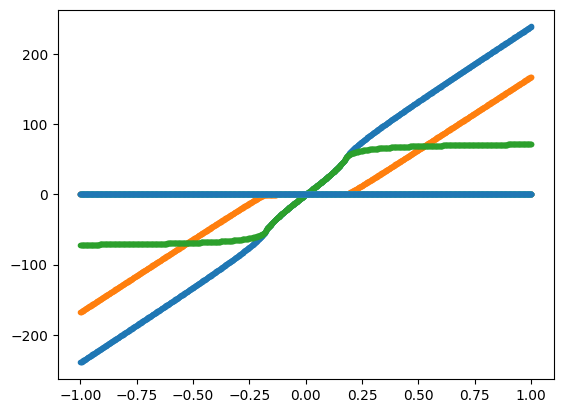

In [ ]:
import matplotlib.pyplot as plt

plt.plot(V_mV, I_nA, ".")
for i in range(np.shape(Ix_nA)[1]):
    plt.plot(V_mV, Ix_nA[:, i], ".")

In [ ]:
from superconductivity.models.bcs import get_Ibcs_nA
from superconductivity.utilities.binning import bin
from superconductivity.utilities.upsampling import upsample
from superconductivity.utilities.constants import G0_muS
import numpy as np

Vbias_mV = np.linspace(-0.5, 0.5, 1001)
Abias_mV = np.linspace(0, 0.3, 1001)
Ibias_nA = np.linspace(-10, 10, 1001)

GN_G0 = 0.2
I_nA = get_Ibcs_nA(
    V_mV=Vbias_mV,
    GN_G0=GN_G0,
    T_K=0.236,
    Delta_meV=0.18,
    gamma_meV=0.00,
    A_mV=Abias_mV,
    nu_GHz=10.0,
)
temp = upsample((Vbias_mV, I_nA), N_up=200, axis=1)
V_mV = bin(*temp, Ibias_nA, axis=1)

dIdV_G0 = np.gradient(I_nA, Vbias_mV, axis=1) / G0_muS
dVdI_R0 = np.gradient(V_mV, Ibias_nA, axis=1) * G0_muS

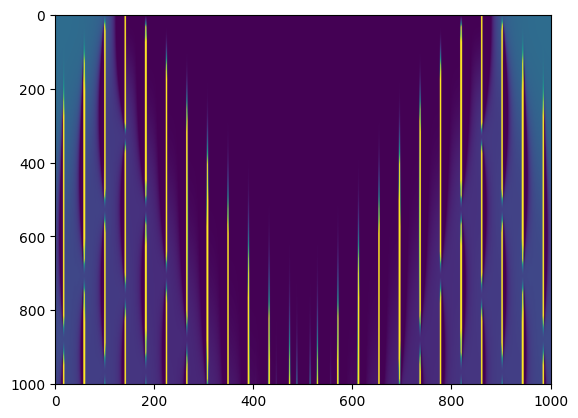

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(dIdV_G0, aspect="auto", vmin=0, vmax=GN_G0 * 3)

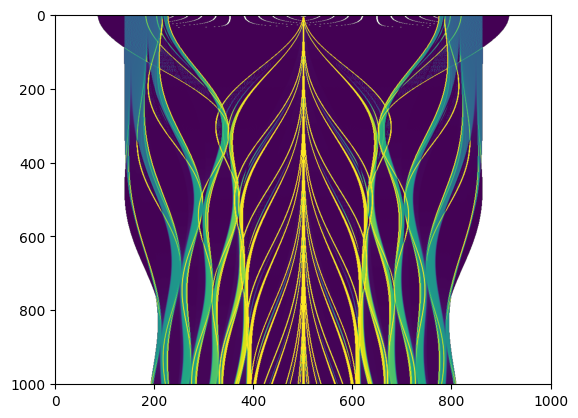

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(dVdI_R0, aspect="auto", vmin=0, vmax=3 / GN_G0)